## 1 General settings

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import math
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['pdf.fonttype'] = 42

In [2]:
pal = {"Lenti-SIINFEKL":"#FF6982",
      "Lenti-mCherry":"#800020",
      "Lenti-Control":"#E6E6E6"}

In [3]:
def LN_Mean(input_vector):
    log_vector = np.log(input_vector)
    temp_mean = log_vector.mean()
    temp_var = log_vector.var()
    return (math.exp(temp_mean + 0.5*temp_var))
def generate_mouse_summary_and_ratio(query_df, temp_intermediate_dic):
    # Aggregate Mouse_summary_df for mouse-level values
    Mouse_summary_df = (
        query_df.groupby(['Sample_ID', 'Vector_type', 'Mouse_genotype'], as_index=False)
        .agg(
            TTN=('gRNA_clonalbarcode', 'count'),
            TTB=('Cell_number', 'sum'),
            LN_mean_tumor_size=('Cell_number', LN_Mean),
            Median_tumor_size=('Cell_number', np.median),
            P95_tumor_size=('Cell_number', lambda x: np.percentile(x, 95))
        )
    )
    
    # Normalize metrics to per 100K virus
    Mouse_summary_df['Tumor number per 100K virus'] = Mouse_summary_df['TTN'] / Mouse_summary_df['Mouse_genotype'].map(temp_intermediate_dic)
    Mouse_summary_df['Total tumor burden per 100K virus (log10)'] = np.log10(Mouse_summary_df['TTB'] / Mouse_summary_df['Mouse_genotype'].map(temp_intermediate_dic))
    Mouse_summary_df['LN_mean_tumor_size (log10)'] = np.log10(Mouse_summary_df['LN_mean_tumor_size'])
    Mouse_summary_df['P95_tumor_size (log10)'] = np.log10(Mouse_summary_df['P95_tumor_size'])
    # Generate ratio DataFrame
    
    # Reshape to long format for easier calculation of ratios
    long_df = Mouse_summary_df.melt(id_vars=['Sample_ID', 'Vector_type'], 
                                    value_vars=['TTN', 'TTB', 'Median_tumor_size', 'LN_mean_tumor_size', 'P95_tumor_size'], 
                                    var_name='Metric', value_name='Value')

    # Separate the control rows for merging
    control_df = long_df[long_df['Vector_type'] == 'Lenti-Control'][['Sample_ID', 'Metric', 'Value']].rename(columns={'Value': 'Control_Value'})

    # Filter out the target rows for 'Lenti-SIINFEKL' and 'Lenti-mCherry'
    target_df = long_df[long_df['Vector_type'].isin(['Lenti-SIINFEKL', 'Lenti-mCherry'])]

    # Merge control values into the target rows based on Sample_ID and Metric
    normalized_df = target_df.merge(control_df, on=['Sample_ID', 'Metric'])

    # Calculate normalized values by dividing the target Value by the control Value
    normalized_df['Normalized_Value'] = normalized_df['Value'] / normalized_df['Control_Value']

    # Select the relevant columns for the final normalized DataFrame
    Mouse_ratio_df = normalized_df[['Sample_ID', 'Metric', 'Vector_type', 'Normalized_Value']].copy()
    
    # Map metric names for readability
    mapping2 = {
        'TTN': 'Total tumor number',
        'TTB': 'Total tumor burden',
        'P95_tumor_size': 'Tumor size at 95th percentile',
        'LN_mean_tumor_size': 'LN mean tumor size',
        'Median_tumor_size': 'Median tumor size'
    }
    Mouse_ratio_df['Metric'] = Mouse_ratio_df['Metric'].replace(mapping2)
    
    # Sort the DataFrame for final output
    Mouse_ratio_df = Mouse_ratio_df.sort_values(by='Vector_type', ascending=False)
    
    return Mouse_summary_df, Mouse_ratio_df

In [4]:
mapping = {
    'NI': 'Lenti-Control',
    'MI': 'Lenti-mCherry',
    'HI': 'Lenti-SIINFEKL'
}

In [5]:
excluded_sample = ['29536', '29837', '29915']

In [6]:
# combined barcode dataframe address
raw_reads_address = '../02_data_cleaning_and_QC/data/Immunoediting_raw_final_df.parquet'

In [7]:
raw_df = pd.read_parquet(raw_reads_address)
# exclude the sample with low quality
raw_df = raw_df[~raw_df.Sample_ID.isin(excluded_sample)]
raw_df['Log10CN'] = np.log10(raw_df['Cell_number'])
# Apply the mapping to the 'Vector_type' column
raw_df['Vector_type'] = raw_df['Vector_type'].replace(mapping)
raw_df = raw_df[raw_df['Identity']=='gRNA']
raw_df.loc[raw_df.Targeted_gene_name.str.contains('NT|Neo'),'Targeted_gene_name'] = 'Inert'
KC_df = raw_df[raw_df.Mouse_genotype=='KTC']
K_df = raw_df[raw_df.Mouse_genotype=='KT']

In [8]:
len(KC_df['Sample_ID'].unique())

24

## 2 Fig. 5F

In [9]:
# All tumors from K mice or Inert tumors from KC mice

In [10]:
query_df = raw_df[(raw_df.Mouse_genotype=='KT')|((raw_df.Mouse_genotype=='KTC')&(raw_df.Targeted_gene_name.isin(['Inert'])))]
query_df = query_df[query_df.Cell_number>=100].copy()

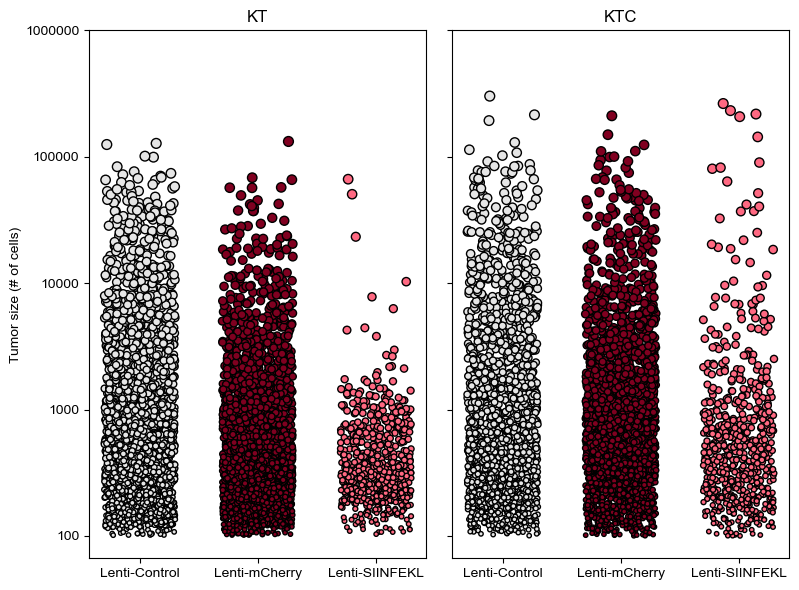

In [11]:
# Fig. 5F: swarm by mouse genotype (KT vs KTC); x = vector type
axis_group = 'Vector_type'
temp_new_g = axis_group + '_codes'

temp_df = query_df.copy()
mouse_g_order = ['KT', 'KTC']

fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
vector_order = ["Lenti-Control", "Lenti-mCherry", "Lenti-SIINFEKL"]

for i, mouse_g in enumerate(mouse_g_order):
    ax = axes[i]
    temp_df_subset = temp_df[temp_df['Mouse_genotype'] == mouse_g].sample(frac=0.1, random_state=1)

    temp_df_subset[axis_group] = temp_df_subset[axis_group].astype('category')
    temp_df_subset[axis_group] = temp_df_subset[axis_group].cat.set_categories(vector_order, ordered=True)
    temp_df_subset = temp_df_subset.sort_values(by=axis_group)
    temp_df_subset[temp_new_g] = temp_df_subset[axis_group].cat.codes + np.random.uniform(-0.3, 0.3, temp_df_subset.shape[0])

    temp_df_subset['Log10CN'] = np.log10(temp_df_subset['Cell_number'])

    sns.scatterplot(
        x=temp_new_g, y='Log10CN', data=temp_df_subset, ax=ax,
        size='Log10CN', hue='Vector_type', palette=pal,
        edgecolor="black", linewidth=1, sizes=(10, 50), legend=False
    )

    ax.set_title(mouse_g)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks(np.arange(len(temp_df_subset[axis_group].cat.categories)))
    ax.set_xticklabels(temp_df_subset[axis_group].cat.categories)
    ax.set_yticks([2, 3, 4, 5, 6])
    ax.set_yticklabels(['100', '1000', '10000', '100000', '1000000'])

fig.text(0, 0.5, 'Tumor size (# of cells)', va='center', rotation='vertical')
plt.tight_layout()
plt.show()


## 3 Fig. 5 G-H and Fig. S11 C-F

In [12]:
# virus titer conversion (per 100K virus normalization)
temp_intermediate_dic = {'KTC': 0.6, 'KT': 1}


In [13]:
# K with all tumor
query_df = K_df[K_df.Cell_number>100]
Mouse_summary_df, Mouse_ratio_df = generate_mouse_summary_and_ratio(query_df, temp_intermediate_dic)
df1 = Mouse_ratio_df.copy()
df1['Group'] = 'K_All'

# KC with Inert tumor
query_df = KC_df[(KC_df.Cell_number>100)&(KC_df.Targeted_gene_name.str.contains('Neo|NT|Inert'))]
Mouse_summary_df, Mouse_ratio_df = generate_mouse_summary_and_ratio(query_df, temp_intermediate_dic)
df2 = Mouse_ratio_df.copy()
df2['Group'] = 'KC_Inert'

# KC with all TSG and Inert
# I didn't include B2M and PDL1 here
query_gene_list = ['Lkb1','Setd2','Rb1','Trp53','Apc', 'Rbm10',
                   'Smad4','Cdkn2a','Arid1a','Atm','Keap1', 'Inert']
query_df = KC_df[(KC_df.Cell_number>100)&(KC_df.Targeted_gene_name.isin(query_gene_list))]

Mouse_summary_df, Mouse_ratio_df = generate_mouse_summary_and_ratio(query_df, temp_intermediate_dic)
df3 = Mouse_ratio_df.copy()
df3['Group'] = 'KC_All'

# combine 
Combined_df = pd.concat([df1,df2,df3],ignore_index=True)

/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_2837/3473444152.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Vector_type', y='Normalized_Value', data=temp_p_df, ax=ax_temp, palette=pal)
/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_2837/3473444152.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_2837/3473444152.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Vector_type', y='Normalized_Value', data=temp_p_df, ax=ax_temp, palette=pal)


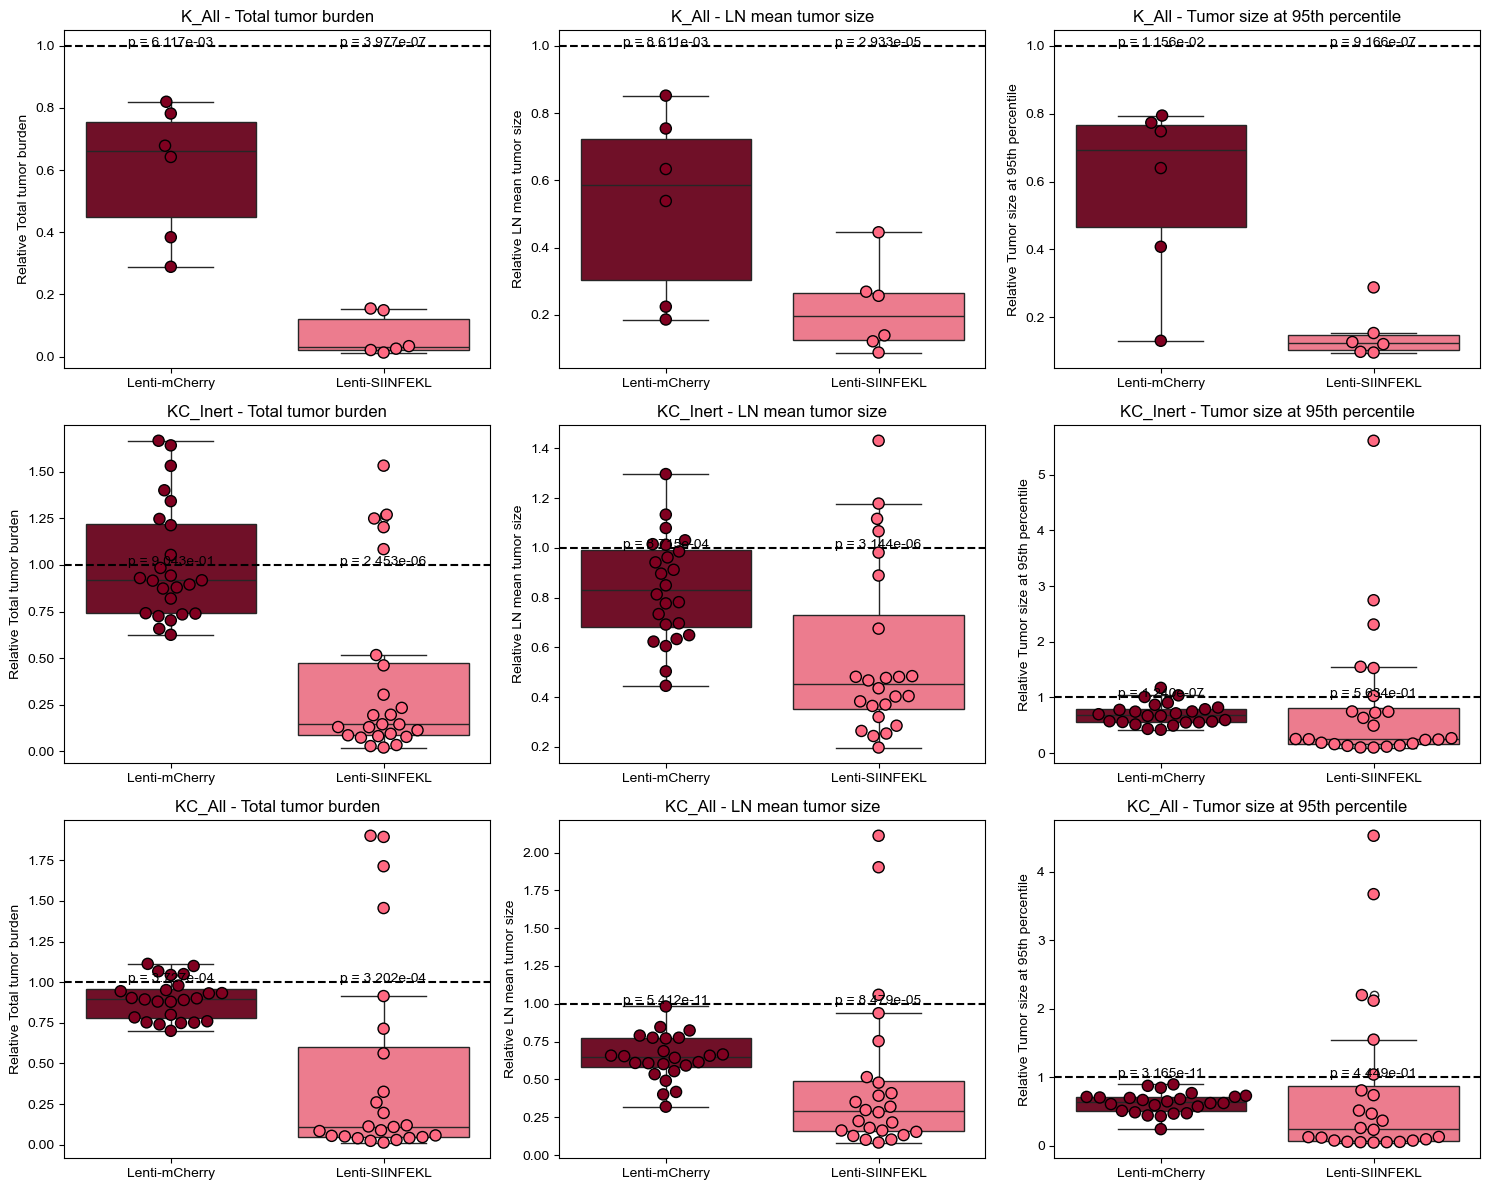

In [14]:
input_df = Combined_df
input_metric = ['Total tumor burden', 'LN mean tumor size', 'Tumor size at 95th percentile']
input_group = ['K_All', 'KC_Inert', 'KC_All']

fig, axs = plt.subplots(3, 3, figsize=(15, 12))

for n1, group in enumerate(input_group):
    for n2, metric in enumerate(input_metric):
        ax_temp = axs[n1, n2]
        temp_p_df = input_df[(input_df.Group == group) & (input_df.Metric == metric)]
        sns.boxplot(x='Vector_type', y='Normalized_Value', data=temp_p_df, ax=ax_temp, palette=pal)
        sns.swarmplot(
            x='Vector_type',
            y='Normalized_Value',
            data=temp_p_df,
            ax=ax_temp,
            size=8,
            edgecolor="black",
            linewidth=1,
            palette=pal
        )
        grouped = temp_p_df.groupby('Vector_type')
        temp_label = f'Relative {metric}'
        ax_temp.set_ylabel(temp_label)
        ax_temp.set_xlabel('')

        for vector_type, group2 in grouped:
            _, p_value = stats.ttest_1samp(group2['Normalized_Value'], 1)
            x_pos = list(temp_p_df['Vector_type'].unique()).index(vector_type)
            # Always show the exact p-value (to 3 decimals), no "p < 0.001"
            p_text = f"p = {p_value:.3e}"
            ax_temp.text(x_pos, 1, p_text, ha='center', color='black')
        ax_temp.axhline(y=1, color='black', linestyle='--')
        ax_temp.set_title(f"{group} - {metric}")

plt.tight_layout()
plt.show()


/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_2837/4042274628.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Vector_type', y='Normalized_Value', data=temp_p_df, ax=ax_temp, palette=pal)
/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_2837/4042274628.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_2837/4042274628.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Vector_type', y='Normalized_Value', data=temp_p_df, ax=ax_temp, palette=pal)


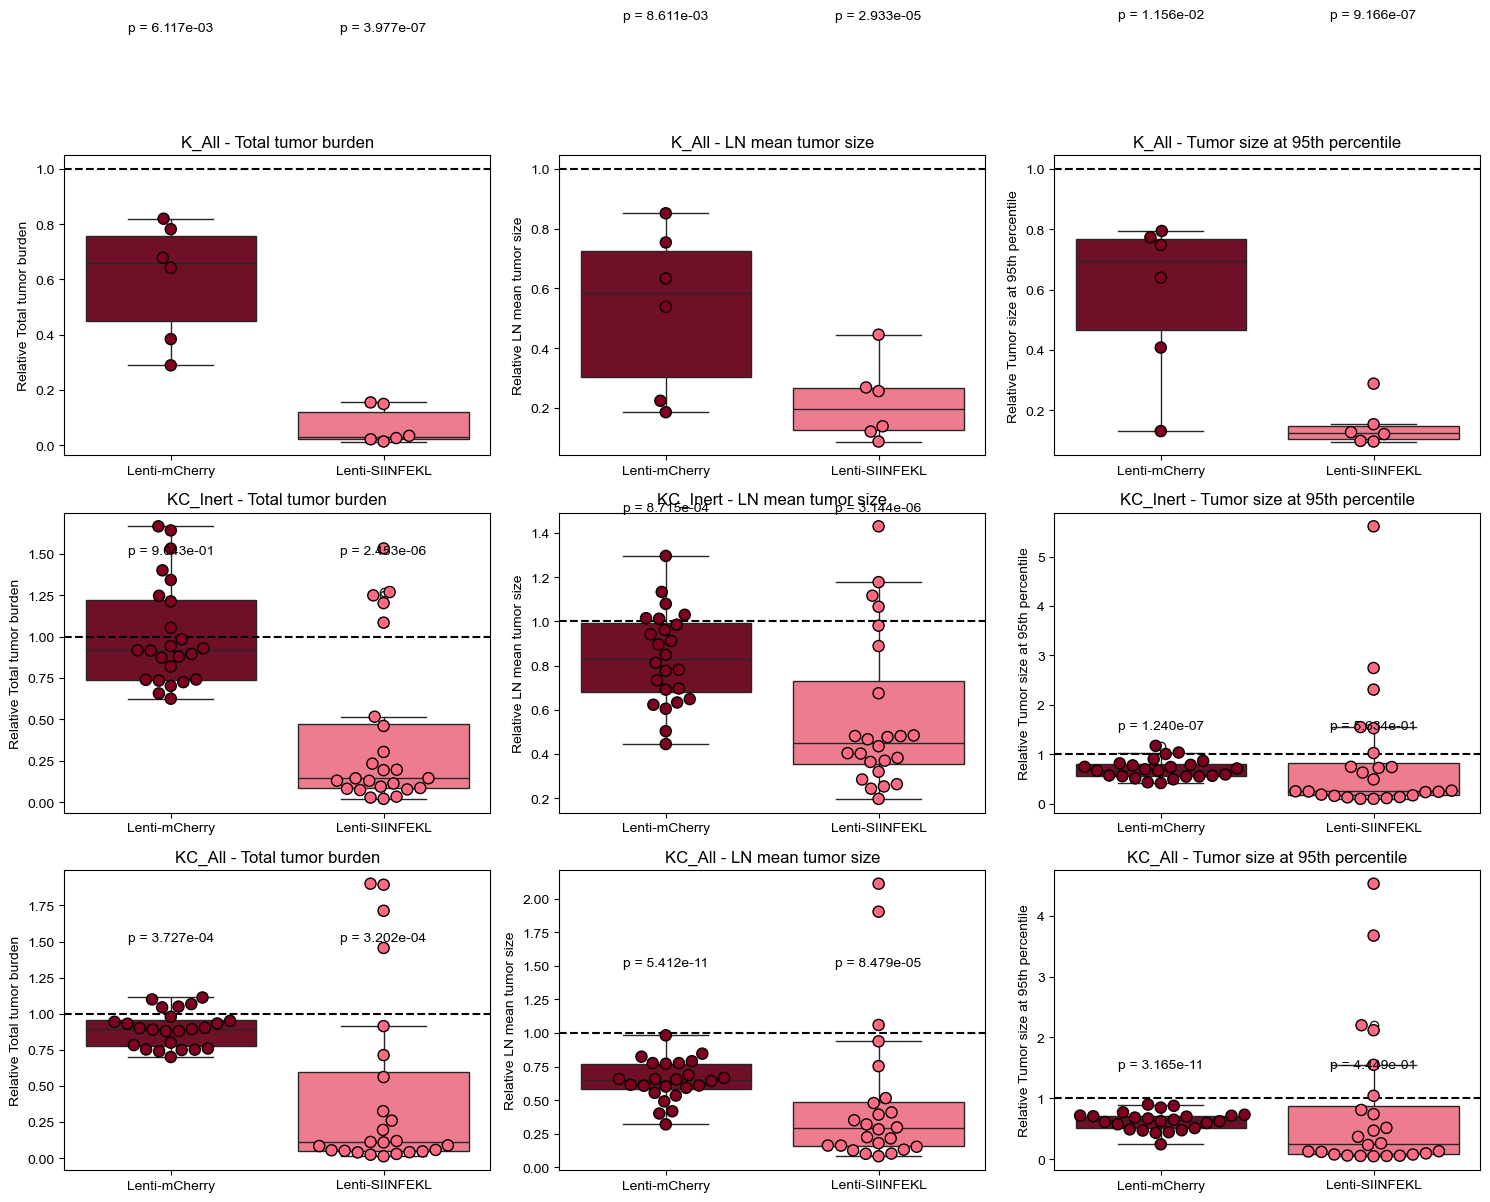

In [15]:
input_df = Combined_df
input_metric = ['Total tumor burden', 'LN mean tumor size', 'Tumor size at 95th percentile']
input_group = ['K_All', 'KC_Inert', 'KC_All']

fig, axs = plt.subplots(3, 3, figsize=(15, 12))

for n1, group in enumerate(input_group):
    for n2, metric in enumerate(input_metric):
        ax_temp = axs[n1, n2]
        temp_p_df = input_df[(input_df.Group == group) & (input_df.Metric == metric)]
        sns.boxplot(x='Vector_type', y='Normalized_Value', data=temp_p_df, ax=ax_temp, palette=pal)
        sns.swarmplot(
            x='Vector_type',
            y='Normalized_Value',
            data=temp_p_df,
            ax=ax_temp,
            size=8,
            edgecolor="black",
            linewidth=1,
            palette=pal
        )
        grouped = temp_p_df.groupby('Vector_type')
        temp_label = f'Relative {metric}'
        ax_temp.set_ylabel(temp_label)
        ax_temp.set_xlabel('')

        for vector_type, group2 in grouped:
            _, p_value = stats.ttest_1samp(group2['Normalized_Value'], 1)
            x_pos = list(temp_p_df['Vector_type'].unique()).index(vector_type)
            # Always show the exact p-value (to 3 decimals), no "p < 0.001"
            p_text = f"p = {p_value:.3e}"
            ax_temp.text(x_pos, 1.5, p_text, ha='center', color='black')
        ax_temp.axhline(y=1, color='black', linestyle='--')
        ax_temp.set_title(f"{group} - {metric}")

plt.tight_layout()
plt.show()


## 4 Fig. S12

In [16]:
query_df = KC_df[KC_df.Targeted_gene_name.isin(['Inert','Lkb1'])]
query_df = query_df[query_df.Cell_number>=100].copy()

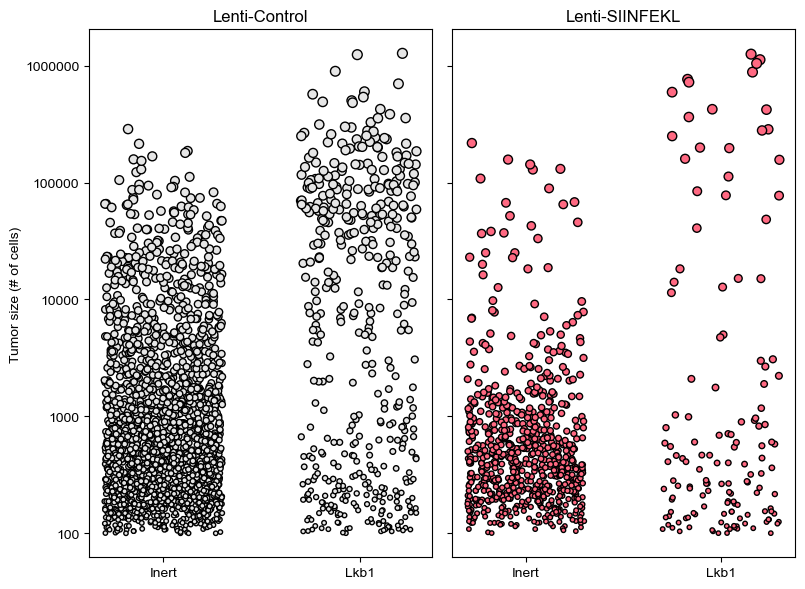

In [17]:
# Fig. S12: Lkb1 vs Inert by vector (excluding mCherry panel)
axis_group = 'Targeted_gene_name'
temp_new_g = axis_group + '_codes'

temp_df = query_df[query_df.Vector_type != 'Lenti-mCherry']
vector_order = ["Lenti-Control", "Lenti-SIINFEKL"]

fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

for i, vector_type in enumerate(vector_order):
    ax = axes[i]
    temp_df_subset = temp_df[temp_df['Vector_type'] == vector_type].sample(frac=0.1, random_state=1)
    temp_df_subset = temp_df_subset.sort_values(by=axis_group)

    temp_df_subset[axis_group] = temp_df_subset[axis_group].astype('category')
    temp_df_subset[axis_group] = temp_df_subset[axis_group].cat.set_categories(
        temp_df_subset[axis_group].unique(), ordered=True
    )
    temp_df_subset[temp_new_g] = temp_df_subset[axis_group].cat.codes + np.random.uniform(-0.3, 0.3, temp_df_subset.shape[0])

    temp_df_subset['Log10CN'] = np.log10(temp_df_subset['Cell_number'])

    sns.scatterplot(
        x=temp_new_g, y='Log10CN', data=temp_df_subset, ax=ax,
        size='Log10CN', hue='Vector_type', palette=pal,
        edgecolor="black", linewidth=1, sizes=(10, 50), legend=False
    )

    ax.set_title(vector_type)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks(np.arange(len(temp_df_subset[axis_group].cat.categories)))
    ax.set_xticklabels(temp_df_subset[axis_group].cat.categories)
    ax.set_yticks([2, 3, 4, 5, 6])
    ax.set_yticklabels(['100', '1000', '10000', '100000', '1000000'])

fig.text(0, 0.5, 'Tumor size (# of cells)', va='center', rotation='vertical')
plt.tight_layout()
plt.show()
